
✅ Accuracy on test set: 0.9762

📊 Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00

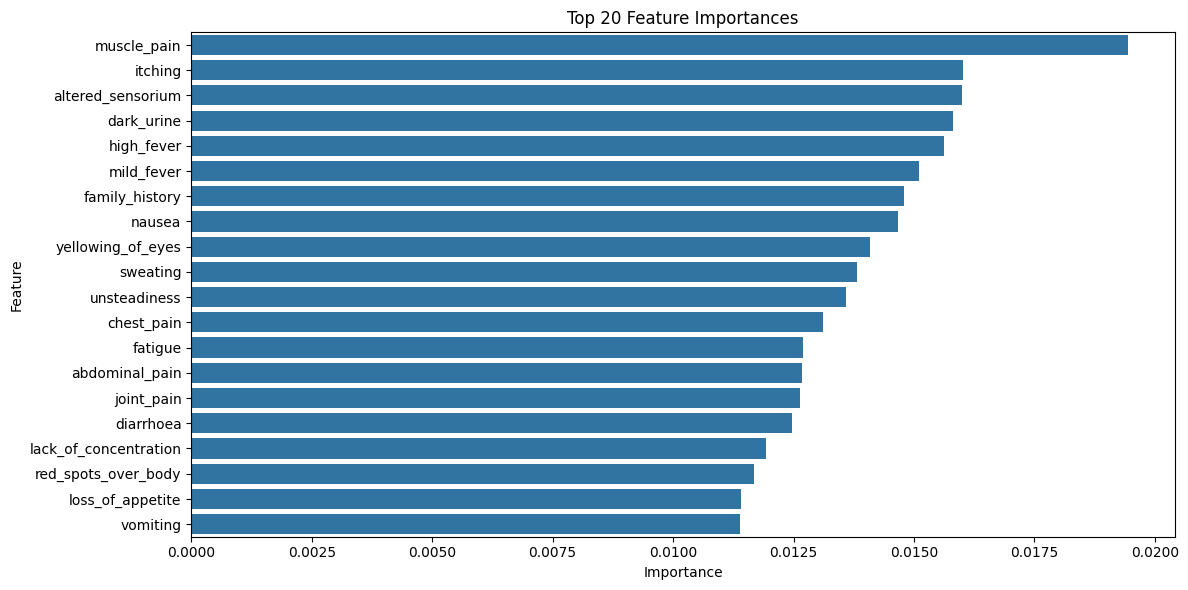

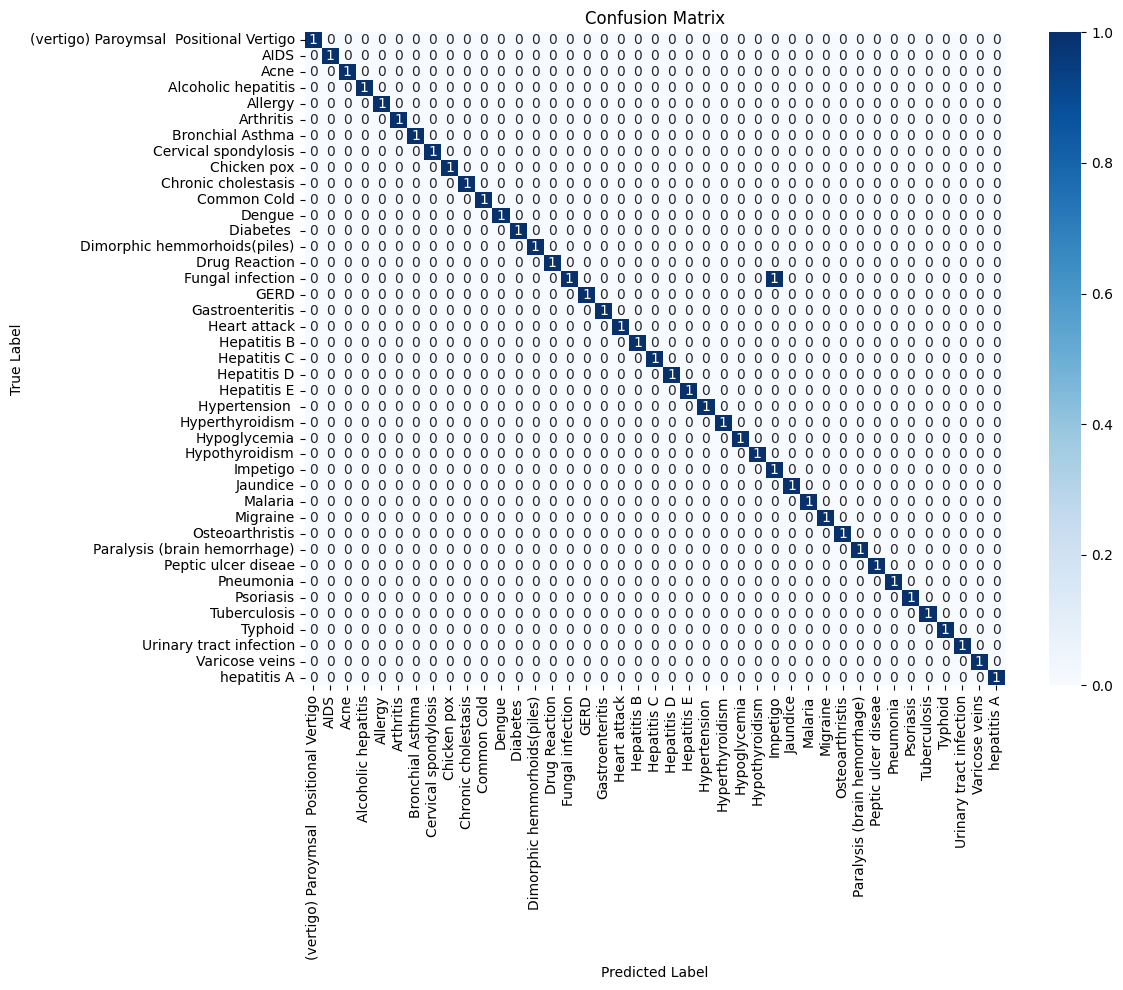

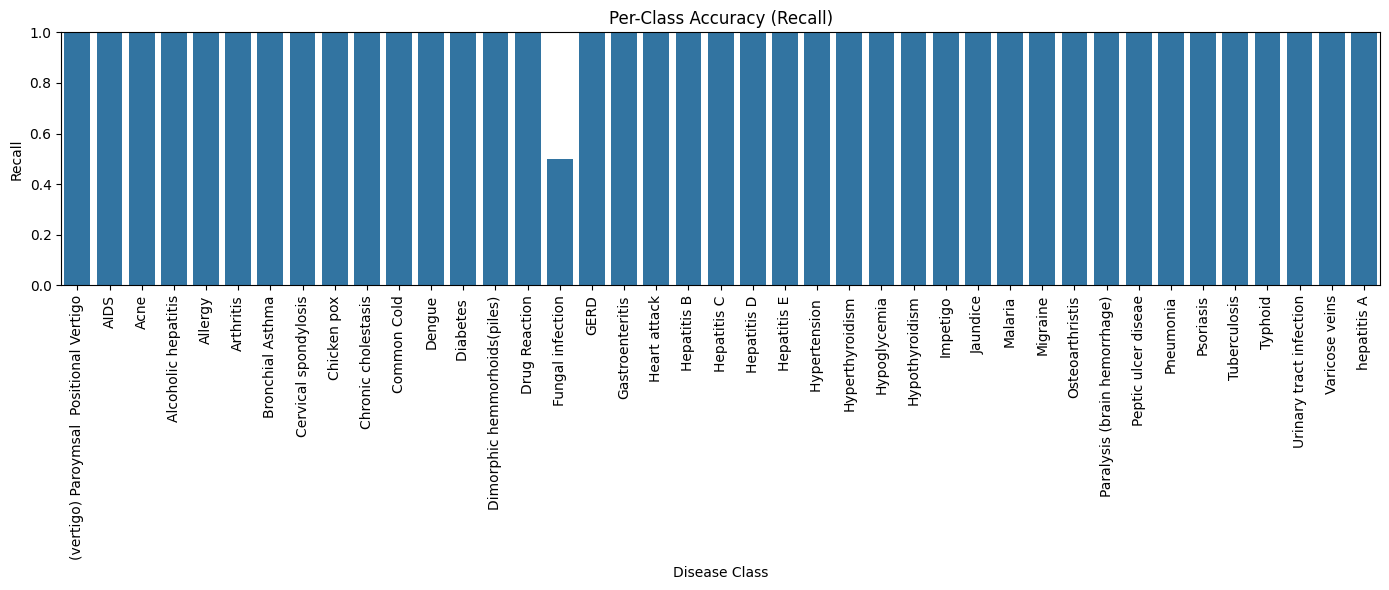

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import dump, load
import os

# STEP 1: Load and Clean Training Data
train_df = pd.read_csv("training_data.csv")
train_df = train_df.loc[:, ~train_df.columns.str.contains('^Unnamed')]

# STEP 2: Load and Clean Test Data
test_df = pd.read_csv("test_data.csv")
test_df = test_df.loc[:, ~test_df.columns.str.contains('^Unnamed')]

# STEP 3: Prepare Features and Labels
X_train = train_df.drop(columns=["prognosis"])
y_train = train_df["prognosis"]

X_test = test_df.drop(columns=["prognosis"])
y_test = test_df["prognosis"]

# STEP 4: Encode Labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# STEP 5: Train Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train_encoded)

# STEP 6: Predict and Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test_encoded, y_pred)

print(f"\n✅ Accuracy on test set: {acc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

# STEP 7: Save Model and Encoder
os.makedirs("saved_model", exist_ok=True)
dump(clf, "saved_model/random_forest.joblib")
dump(label_encoder, "saved_model/label_encoder.joblib")

print("\n💾 Model and label encoder saved in 'saved_model/' directory.")

# ======= 🔍 VISUALIZATIONS ======= #

# 🎯 Feature Importance
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # top 20 features
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=X_train.columns[indices])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 📊 Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# 📈 Accuracy per Class
report = classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_, output_dict=True)
per_class_accuracy = [report[label]["recall"] for label in label_encoder.classes_]

plt.figure(figsize=(14, 6))
sns.barplot(x=label_encoder.classes_, y=per_class_accuracy)
plt.title("Per-Class Accuracy (Recall)")
plt.xlabel("Disease Class")
plt.ylabel("Recall")
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
